<a href="https://colab.research.google.com/github/ashwinij-7/Machine-Learning/blob/main/Gaussian_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import dataset

In [1]:
import kagglehub
import os
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("gokulsml/gaussian-naive-bayes")

print("Path to dataset files:", path)

100%|██████████| 2.02k/2.02k [00:00<00:00, 2.86MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gokulsml/gaussian-naive-bayes/versions/1


In [2]:
print(os.listdir(path))

['Naive-Bayes-Classification-Data.csv']


In [3]:
csv_path = os.path.join(path, 'Naive-Bayes-Classification-Data.csv')
df = pd.read_csv(csv_path)

print(df.head())

   glucose  bloodpressure  diabetes
0       40             85         0
1       40             92         0
2       45             63         1
3       45             80         0
4       40             73         1


Model Training

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [5]:
X = df[['bloodpressure',
        'glucose']]
y = df['diabetes']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

Evaluation

In [8]:
y_pred = model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9296482412060302


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        93
           1       0.93      0.93      0.93       106

    accuracy                           0.93       199
   macro avg       0.93      0.93      0.93       199
weighted avg       0.93      0.93      0.93       199



In [11]:
train_pred = model.predict(X_train)

# Testing predictions
test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9346733668341709
Testing Accuracy: 0.9296482412060302


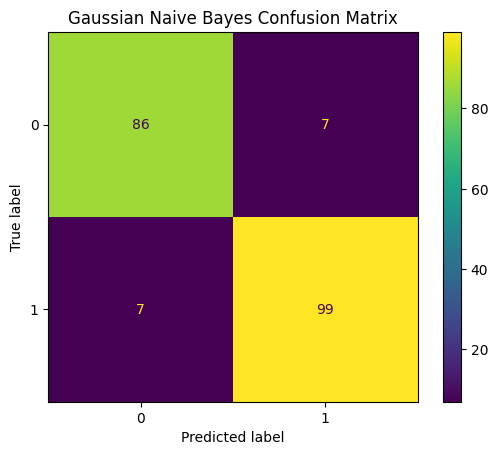

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.show()

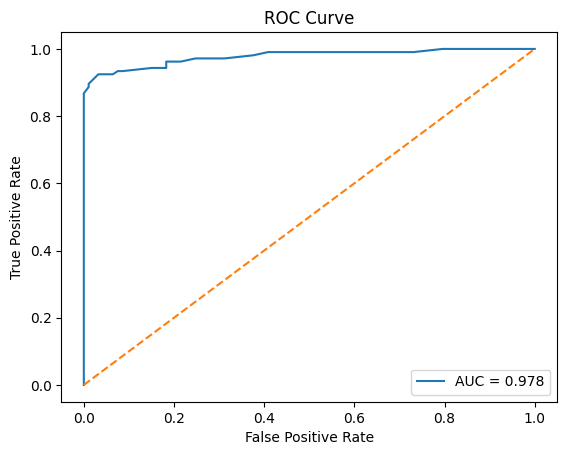

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()